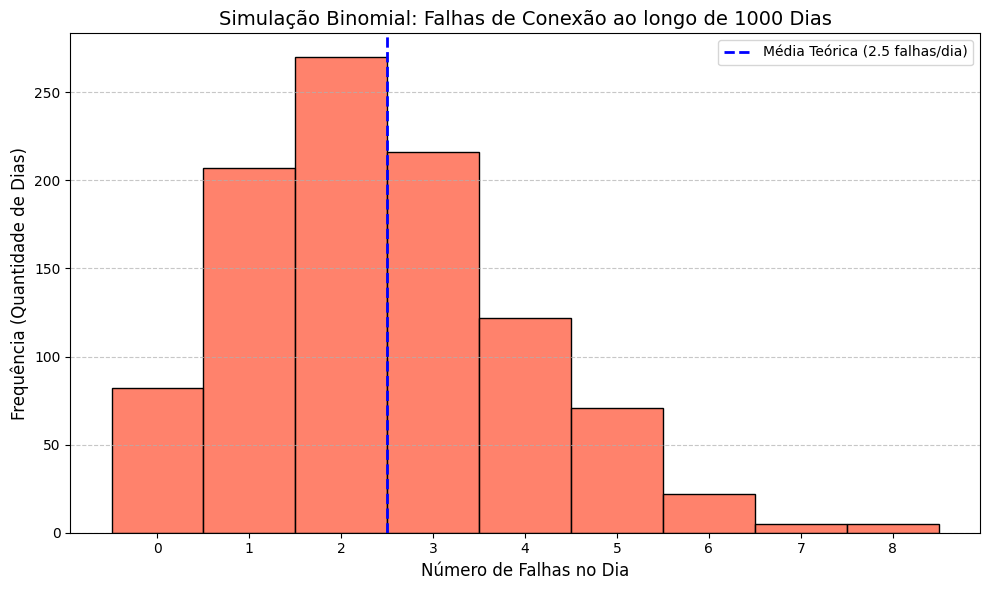

In [ ]:
# Gabarito do exercício 1
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Definindo os Parâmetros do Exercício
# ==========================================
dias_simulados = 1000  # Total de dias (tamanho da amostra / size)
n_conexoes = 50        # Tentativas de conexão por dia (n)
prob_falha = 0.05      # Chance de cada conexão falhar (p)

# ==========================================
# 2. Executando a Simulação
# ==========================================
# O numpy vai gerar um array com 1000 números.
# Cada número representa a quantidade de conexões que falharam em um dia específico.
falhas_diarias = np.random.binomial(n=n_conexoes, p=prob_falha, size=dias_simulados)

# ==========================================
# 3. Gerando o Gráfico (Histograma)
# ==========================================
plt.figure(figsize=(10, 6))

# Usamos discrete=True porque não existe "meia falha" (é uma distribuição discreta)
sns.histplot(falhas_diarias, discrete=True, color='tomato', alpha=0.8, edgecolor='black')

# ==========================================
# 4. Ajustes Estéticos e Linha de Média
# ==========================================
plt.title(f'Simulação Binomial: Falhas de Conexão ao longo de {dias_simulados} Dias', fontsize=14)
plt.xlabel('Número de Falhas no Dia', fontsize=12)
plt.ylabel('Frequência (Quantidade de Dias)', fontsize=12)

# Destacando a média esperada estatisticamente (n * p = 50 * 0.05 = 2.5)
media_esperada = n_conexoes * prob_falha
plt.axvline(media_esperada, color='blue', linestyle='--', linewidth=2,
            label=f'Média Teórica ({media_esperada} falhas/dia)')

# Forçar o eixo X a mostrar todos os números inteiros que ocorreram
plt.xticks(range(min(falhas_diarias), max(falhas_diarias) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

--- ANÁLISE ESTATÍSTICA ---
A probabilidade teórica de uma requisição dar timeout (>150ms) é de 2.2750%

--- SIMULAÇÃO PRÁTICA ---
Em 10.000 requisições simuladas, 237 deram timeout.
A taxa real de falha na simulação foi de 2.3700%


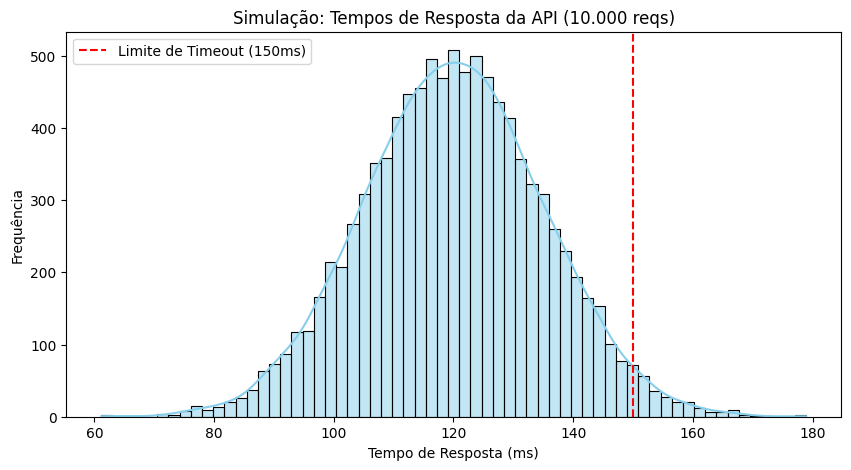

In [ ]:
# Gabarito do exercício 2
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parâmetros da API definidos no exercício
media_ms = 120
desvio_padrao_ms = 15
limite_timeout = 150

# ==========================================
# PARTE A: Cálculo Estatístico Teórico
# ==========================================
# norm.sf (Survival Function) calcula exatamente a probabilidade de X ser MAIOR que um valor.
# É o equivalente a fazer: 1 - norm.cdf(150, 120, 15)
probabilidade_teorica = norm.sf(limite_timeout, loc=media_ms, scale=desvio_padrao_ms)

print("--- ANÁLISE ESTATÍSTICA ---")
print(f"A probabilidade teórica de uma requisição dar timeout (>150ms) é de {probabilidade_teorica:.4%}\n")

# ==========================================
# PARTE B: Simulação Computacional (10.000 requisições)
# ==========================================
# Gerando 10 mil requisições seguindo a curva normal
np.random.seed(42) # Mantém os dados iguais toda vez que rodar
tempos_simulados = np.random.normal(loc=media_ms, scale=desvio_padrao_ms, size=10000)

# Filtrando o array para achar apenas quem passou de 150ms
timeouts_ocorridos = np.sum(tempos_simulados > limite_timeout)
taxa_simulada = timeouts_ocorridos / 10000

print("--- SIMULAÇÃO PRÁTICA ---")
print(f"Em 10.000 requisições simuladas, {timeouts_ocorridos} deram timeout.")
print(f"A taxa real de falha na simulação foi de {taxa_simulada:.4%}")

# ==========================================
# Visualização
# ==========================================
plt.figure(figsize=(10, 5))
sns.histplot(tempos_simulados, kde=True, color='skyblue')
plt.axvline(limite_timeout, color='red', linestyle='--', label=f'Limite de Timeout ({limite_timeout}ms)')

plt.title('Simulação: Tempos de Resposta da API (10.000 reqs)')
plt.xlabel('Tempo de Resposta (ms)')
plt.ylabel('Frequência')
plt.legend()
plt.show()